# 01 — IEEE-CIS Fraud Detection: 기초 EDA

원본 CSV에서 데이터 구조, 결측, 사기 비율, 시간 차이와 ProductCD별 특성을 확인한다.
학습은 [baseline.ipynb](../experiments/baseline/baseline.ipynb)에서 한다.

- [대회](https://www.kaggle.com/competitions/ieee-fraud-detection)
- [참고 코드: Model2](https://github.com/choco9966/IEEE-CIS-Fraud-Detection/blob/main/Model2.ipynb)
- 타깃: `isFraud`, 평가지표: ROC AUC. `TransactionDT`는 기준 시점으로부터의 초다.

각 절은 **무엇을 하나 → 왜 하나 → 원리 → 기대 결과 → 관찰** 순서로 읽는다.
관찰 수치는 실행 결과에서 확인한다. `NROWS=None`이면 전체 원본 데이터를 분석한다.

## 이 노트북을 읽는 방법

코드를 실행하기 전에 바로 위의 설명을 읽어보세요. **어떤 질문을 푸는지 → 작은 예시로 계산 → 실제 코드의 변수와 연결 → 출력 해석** 순서로 설명합니다.
코드 아래의 관찰은 이미 저장된 실행 결과를 읽는 안내입니다. '해볼 실험'은 아직 실행하지 않은 제안이며, 실제 결과와 구분했습니다.

처음 읽을 때 함수 이름을 모두 외울 필요는 없습니다. 새 피처를 만날 때마다 **'이 숫자는 무엇을 요약하며, 예측할 때도 알 수 있는가?'**를 물어보세요.
EDA에서 찾은 차이가 모델 성능 개선을 뜻하지는 않습니다. 실험 노트북에서는 **검증 데이터를 정한 뒤 구성 요소 하나씩 비교**해야 개선의 근거를 얻습니다.

처음에는 `01_eda_report` → GitHub `baseline`을 읽고, 이후 `02_winner_eda` → `winner_xgb` → `winner_lgbm` → `winner_catboost` → `winner_blend`로 이어가세요.
우승자 공개 baseline과 최종 우승 제출 전체는 구분합니다.

설명을 보강하면서 학습 코드·기존 표·그래프·실행 범위를 유지했습니다. 이 노트북의 **저장된 출력**과 설정의 **다음 실행 기본값**이 다를 수 있으므로 첫 실행 범위와 metrics를 먼저 확인하세요.


### 처음 만나는 용어는 여기서 잠깐 확인하세요

| 용어 | 여기서 뜻하는 것 |
|---|---|
| 피처(feature) | 모델에 입력할 거래의 정보. 원본 열과 새로 계산한 열 모두 포함 |
| NaN / 결측 | 값이 관측되지 않음. 실제 숫자 0과 다른 상태 |
| fold / validation | 교차검증의 한 분할 / 그 분할에서 평가용으로 제외한 데이터 |
| OOF | 각 train 행을 그 행 없이 학습한 모델로 예측해서 모은 값 |
| smoke | 전체 학습 전에 축소 데이터·rounds로 실행 흐름을 확인하는 실험 |
| leaf | tree에서 조건을 따라 내려간 끝의 구역. 그 구역에 들어온 행에 같은 보정을 줌 |

**제거 실험(ablation)**은 피처나 기법 하나를 뺀 모델을 같은 검증에서 비교하는 방법입니다. '있을 때 좋았으니 도움이 된다'에서 한 걸음 더 나아가 실제 기여를 확인하려는 실험입니다.

## 0. 환경과 원본 CSV

### 거래를 기준으로 붙인다는 것은 무슨 뜻일까요?

`transaction`은 거래마다 한 행이고, `identity`는 그중 일부 거래의 기기·신원 관련 정보입니다. 두 표의 행 번호는 같은 거래를 뜻하지 않습니다. 거래 번호 `TransactionID`가 같을 때만 붙여야 합니다.

| transaction | identity | left join 결과 |
|---|---|---|
| ID 101, 금액 20 | ID 101, mobile | ID 101, 금액 20, mobile |
| ID 102, 금액 80 | 해당 ID 없음 | ID 102, 금액 80, 결측 |

`left join`은 왼쪽 거래를 모두 남깁니다. `inner join`이면 102번이 사라져 'identity가 있는 거래'만 공부하게 됩니다. 그것은 원래 예측해야 할 모집단과 달라집니다.
`validate='one_to_one'`은 같은 ID의 identity가 여러 개여서 한 거래가 두 행으로 늘어나는 실수를 잡습니다. **행을 지우거나 늘리지 않고 정보만 붙이는 것**이 여기서 기대하는 동작입니다.

아래 코드에서는 `load_data`가 그 결합을 담당하고, `train.head()`가 완성된 거래 몇 개를 보여줍니다. test의 `id-xx`도 `id_xx`로 맞춥니다.
`NROWS=None`은 전체 분석입니다. `NROWS=30000`이면 앞부분만 읽으므로 나중의 시간/상품 통계를 전체 데이터 설명으로 사용하면 안 됩니다.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

cwd = Path.cwd()
PROJECT_DIR = next(p for p in (cwd, *cwd.parents) if (p / "source.json").is_file())
sys.path.insert(0, str(PROJECT_DIR))
from data.loader import DATA_FILES, get_data_dir, load_data

NROWS = int(os.environ["IEEE_NROWS"]) if os.getenv("IEEE_NROWS") else None
sns.set_theme(style="whitegrid", context="notebook")
data_dir = get_data_dir()
print("data_dir:", data_dir)
display(pd.Series({name: round((data_dir / name).stat().st_size / 1024**2, 1)
                   for name in DATA_FILES}, name="size_MB").to_frame())
train, test = load_data(nrows=NROWS)
print("train:", train.shape, "test:", test.shape, "NROWS:", NROWS)
display(train.head())

data_dir: C:\Users\jiho\.cache\kagglehub\competitions\ieee-fraud-detection


,size_MB
train_transaction.csv,651.7
train_identity.csv,25.3
test_transaction.csv,584.8
test_identity.csv,24.6
sample_submission.csv,5.8


train: (590540, 434) test: (506691, 433) NROWS: None


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


### 출력을 읽고 확인하기
전체 결합 결과는 train 590,540행, test 506,691행입니다. 행은 거래, 열은 거래를 설명하는 정보입니다. identity가 비어 있는 행도 남아 있습니다.
**생각해보기:** identity를 inner join했다면 학습하려는 거래의 구성은 어떻게 바뀔까요? 결측을 없애는 일이 항상 데이터 정리가 되는 것은 아닙니다.

## 1. 구조와 정답 비율

### 96.5% 정확도인데도 모델이 쓸모없을 수 있습니다

`isFraud`는 사기면 1, 정상이면 0입니다. 0/1의 평균은 '1이 나온 비율'이므로 `train.isFraud.mean()`이 사기율입니다.
사기율이 3.5%라면 모든 거래를 정상이라고 해도 accuracy는 96.5%입니다. 이 모델은 사기를 하나도 발견하지 못합니다.

이 대회의 ROC AUC는 **사기 거래에 정상 거래보다 높은 점수를 주었는가**를 평가합니다. 이해를 위해 사기 점수가 .8/.3, 정상 점수가 .6/.1이라고 해볼까요?
사기와 정상의 조합 4개 중 .8은 둘 다 이기고, .3은 .1만 이깁니다. 따라서 AUC는 3/4=.75입니다. 동점은 절반의 승리로 세며, 모두 같은 점수면 .5입니다.
**AUC .9는 거래의 90%를 정확히 분류했다는 뜻도, 사기를 90% 발견했다는 뜻도 아닙니다.** 임계값 없이 두 집단의 순서를 비교한 값입니다.

아래 `assert`는 분석의 전제를 확인합니다. ID가 유일한지, test에 정답이 섞이지 않았는지, 입력 열이 같은지 봅니다.
`features`는 ID와 정답을 뺀 열 수입니다. 입력 후보 열의 개수이지, 실제 모델이 모두 사용한다는 뜻은 아닙니다.

AUC는 순위를 보므로 .1/.2를 .6/.7로 바꿔도 순서가 같다면 달라지지 않습니다. **확률이 실제 사기율에 맞는가**는 별도의 calibration 문제입니다.
지표 정의는 [scikit-learn ROC AUC 문서](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)에서 확인할 수 있습니다.

,value
train_rows,590540.00000
test_rows,506691.00000
features,432.00000
fraud_count,20663.00000
fraud_rate,0.03499
always_normal_accuracy,0.96501


,columns
float64,399
str,31
int64,4


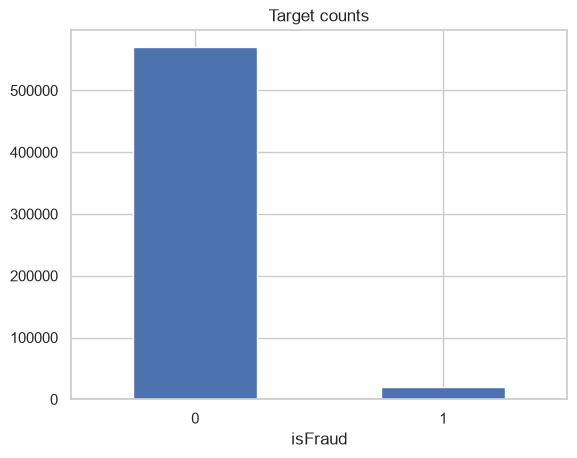

In [2]:
assert train.TransactionID.is_unique and test.TransactionID.is_unique
assert "isFraud" not in test and set(train.isFraud.unique()) == {0, 1}
assert set(train.columns) - {"isFraud"} == set(test.columns)
assert not set(train.TransactionID).intersection(test.TransactionID)

summary = pd.Series({
    "train_rows": len(train), "test_rows": len(test),
    "features": train.shape[1] - 2,
    "fraud_count": int(train.isFraud.sum()),
    "fraud_rate": train.isFraud.mean(),
    "always_normal_accuracy": 1 - train.isFraud.mean(),
})
display(summary.to_frame("value"))
display(train.dtypes.astype(str).value_counts().to_frame("columns"))
train.isFraud.value_counts().sort_index().plot.bar(title="Target counts", rot=0)
plt.show()

### 관찰에서 얻을 수 있는 것
전체 사기는 20,663건, 약 3.499%입니다. accuracy 96.50%라는 쉬운 기준선을 넘어서는 것만으로는 사기 탐지를 입증할 수 없습니다.
여기서는 정답 분포와 ID 검사를 통과했습니다. 다음에는 '이 드문 사기가 어떤 상품/시기/정보 수집 경로에 집중되는가'를 묻습니다.

## 2. 결측과 identity 커버리지

### 결측도 데이터가 생성된 과정의 흔적입니다

`isna()`는 각 값이 비어 있으면 True인 표를 만듭니다. True/False를 1/0처럼 평균내면 열별 결측률이 됩니다.
예를 들어 값 10개 중 7개가 비면 결측률 .7입니다. `test_minus_train=.1`이면 test에서 **10%p 더 많이** 빠졌다는 뜻이지 10% 더 커졌다는 뜻은 아닙니다.

`notna().any(axis=1)`은 한 거래의 identity 관련 열 중 값이 하나라도 있는지 묻습니다. 이것은 '정보가 관측된 거래'를 나누는 분석용 표시입니다.
결측에 0을 채우면 실제 0과 '측정되지 않음'을 구별하기 어려워집니다. 여기서는 먼저 결측을 그대로 관찰합니다. 나중에 모델마다 NaN 또는 별도 범주로 처리합니다.

identity 존재 그룹의 사기율이 높다면, 그 정보의 **값뿐 아니라 수집 여부**도 예측 단서일 수 있습니다. 다만 신원 정보가 있기 때문에 사기가 발생했다고 해석하면 안 됩니다.
상품 종류나 거래 경로가 identity 수집과 사기율 모두에 영향을 줄 수 있습니다. 상품군 안에서 다시 비교해야 그 설명을 더 좁힐 수 있습니다.

아래 표의 `size`를 사기율과 함께 읽으세요. 5건 중 1건 사기와 50,000건 중 10,000건 사기는 같은 20%여도 추정의 안정성이 다릅니다.

,train,test,test_minus_train
id_24,0.991962,0.990645,-0.001316
id_25,0.991310,0.990055,-0.001255
id_08,0.991271,0.990016,-0.001255
id_07,0.991271,0.990016,-0.001255
id_21,0.991264,0.990016,-0.001248
id_26,0.991257,0.990039,-0.001218
id_22,0.991247,0.990010,-0.001237
id_27,0.991247,0.990010,-0.001237
id_23,0.991247,0.990010,-0.001237
dist2,0.936284,0.928090,-0.008193


Identity coverage — train: 0.2442 test: 0.2801


,size,fraud_rate
has_identity,,
False,446307,0.020939
True,144233,0.078470


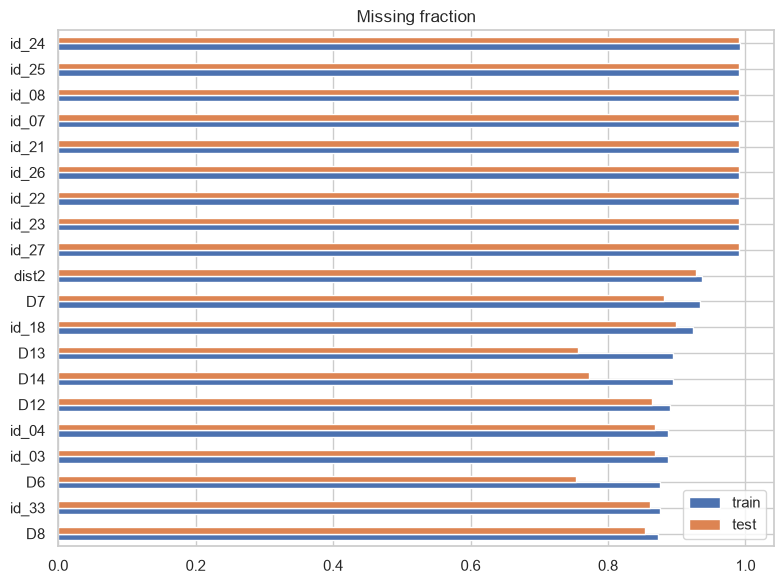

In [3]:
features = train.columns.drop("isFraud")
missing = pd.DataFrame({"train": train[features].isna().mean(),
                        "test": test[features].isna().mean()})
missing["test_minus_train"] = missing.test - missing.train
display(missing.sort_values("train", ascending=False).head(20))
identity_cols = [c for c in features if c.startswith("id_") or c.startswith("Device")]
train_has_identity = train[identity_cols].notna().any(axis=1)
test_has_identity = test[identity_cols].notna().any(axis=1)
print("Identity coverage — train:", round(train_has_identity.mean(), 4),
      "test:", round(test_has_identity.mean(), 4))
display(train.groupby(train_has_identity.rename("has_identity")).isFraud
        .agg(["size", "mean"]).rename(columns={"mean": "fraud_rate"}))
missing.sort_values("train").tail(20)[["train", "test"]].plot.barh(
    figsize=(8, 6), title="Missing fraction")
plt.tight_layout()
plt.show()

### 관찰과 다음 질문
전체 identity 커버리지는 train 24.42%, test 28.01%입니다. 존재/부재 그룹의 사기율은 약 7.85%/2.09%로 다릅니다.
**해볼 분석:** ProductCD 안에서 같은 비교를 해보세요. 상품 구성이 만든 차이인지, 상품 안에서도 정보 수집 여부가 단서인지 분리해서 생각할 수 있습니다. 현재 표만으로 인과관계는 알 수 없습니다.

## 3. 거래 시간과 train/test 차이

### train과 test가 서로 다른 시기에 있습니다

`TransactionDT`는 기준점으로부터 지난 초입니다. 하루는 86,400초이므로 `/86400`은 소수 부분까지 포함한 상대 일수, `//86400`은 거래를 일별 묶음으로 나누는 정수 일수입니다.
첫 그래프의 y축은 거래 수, 두 번째는 해당 날짜의 사기율입니다. **거래가 늘어난 것과 사기율이 높아진 것은 다른 변화**이므로 둘을 나눠 봅니다.

무작위로 행을 섞어 검증하면 같은 시기의 비슷한 거래가 학습과 검증에 함께 들어갑니다. 실제 test가 훨씬 뒤의 거래라면 그 검증은 미래의 변화까지 재현하지 못합니다.
그렇다고 무작위 CV 점수가 무의미한 것은 아닙니다. **'섞인 같은 모집단에서의 일반화'를 측정하며, 우리가 궁금한 미래 예측과 질문이 다르다**고 이해하면 됩니다.

범위 표는 시간의 분리를, 그래프는 거래량과 사기율의 변화를 보여줍니다. 사기율 변화만으로 입력과 정답의 관계까지 바뀌었다고 단정할 수는 없습니다.
입력 분포 변화, 사기율 변화, 같은 입력의 위험도 변화는 구분해서 조사해야 합니다. 다음 EDA의 시간 일관성 검사가 이 질문을 더 직접적으로 다룹니다.

,first_day,last_day
train,1.000000,182.999201
test,213.000278,395.999363


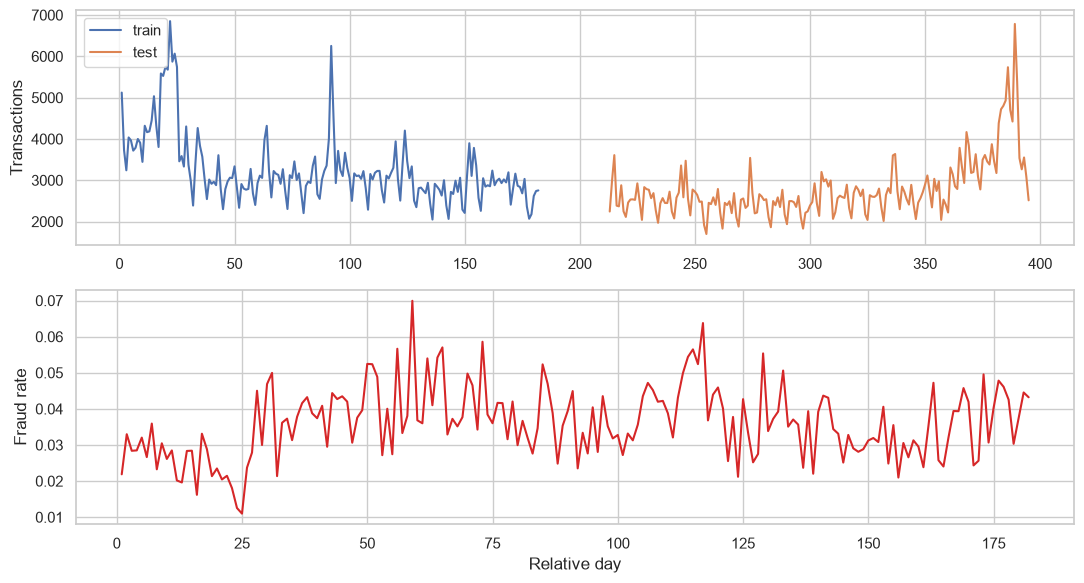

In [4]:
time_range = pd.DataFrame({split: df.TransactionDT.agg(["min", "max"]) / 86400
                           for split, df in (("train", train), ("test", test))}).T
display(time_range.rename(columns={"min": "first_day", "max": "last_day"}))
daily = train.groupby((train.TransactionDT // 86400).rename("day")).isFraud.agg(["size", "mean"])
test_daily = test.groupby(test.TransactionDT // 86400).size()
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(daily.index, daily["size"], label="train")
axes[0].plot(test_daily.index, test_daily, label="test")
axes[0].set_ylabel("Transactions")
axes[0].legend()
axes[1].plot(daily.index, daily["mean"], color="tab:red")
axes[1].set(xlabel="Relative day", ylabel="Fraud rate")
plt.tight_layout()
plt.show()

### 시간 범위가 주는 실험 설계의 단서
저장된 전체 결과의 상대 일수는 train 1–183일, test 213–396일입니다. 두 기간 사이 약 30일의 간격이 있습니다.
**해볼 실험:** 앞 4개월 학습 → 1개월 비움 → 마지막 1개월 검증을 무작위 CV와 비교합니다. 단순히 점수가 낮아졌는지보다 어떤 피처/고객군에서 차이가 나는지 봐야 원인을 좁힐 수 있습니다.

## 4. ProductCD와 거래 금액

### 상품군별 사기율을 보면 모델을 나눌 이유가 보입니다

`groupby('ProductCD')`는 같은 상품 코드를 모읍니다. `rows`는 거래 수, `fraud_rate`는 그 그룹의 정답 평균, `amount_median`은 가운데 금액입니다.
평균은 아주 큰 금액에 영향을 받지만 중앙값은 상대적으로 덜 민감합니다. 둘의 차이가 크면 금액 분포의 긴 꼬리를 의심해볼 수 있습니다.

Model2는 가장 큰 상품군과 나머지를 나눠 학습합니다. 서로 다른 거래 방식과 정보 수집 구조가 있다면 각 모델이 다른 규칙을 배우도록 하는 선택입니다.
하지만 모델을 나누면 작은 그룹의 학습 표본도 줄어듭니다. 상품 코드를 포함한 단일 모델도 분기해서 차이를 배울 수 있으므로 **분리 모델이 항상 이기는 것은 아닙니다.** 같은 검증에서 비교할 가설입니다.

아래 히스토그램은 `log1p(amount)=log(1+amount)`로 큰 금액을 눌러 작은 금액대의 차이도 보이게 합니다. 0도 계산할 수 있습니다.
`common_norm=False`는 정상/사기 각각의 분포 면적을 따로 1로 맞춥니다. 그래서 더 적은 사기 거래의 분포도 볼 수 있습니다. 선 높이가 실제 사기 건수나 그 금액의 사기 확률을 뜻하지는 않습니다.

,rows,fraud_rate,amount_median,amount_mean,identity_coverage,test_rows
ProductCD,,,,,,
W,439670,0.020399,78.500,153.158554,0.000000,360987
C,68519,0.116873,31.191,42.872353,0.907661,69266
R,37699,0.037826,125.000,168.306188,0.995995,35647
H,33024,0.047662,50.000,73.170058,0.996487,29373
S,11628,0.058996,35.000,60.269487,0.996302,11418


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


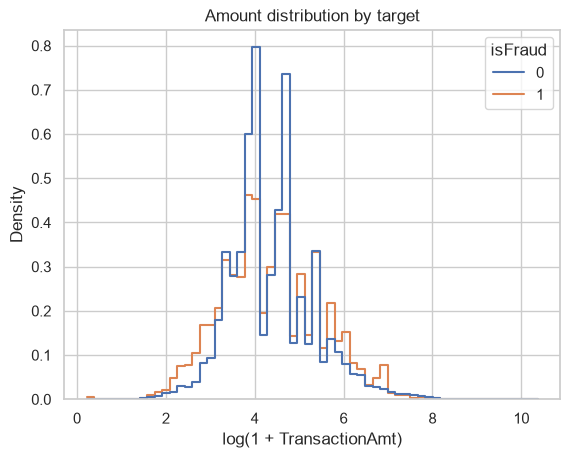

In [5]:
product = train.groupby("ProductCD").agg(
    rows=("isFraud", "size"), fraud_rate=("isFraud", "mean"),
    amount_median=("TransactionAmt", "median"), amount_mean=("TransactionAmt", "mean"))
product["identity_coverage"] = train_has_identity.groupby(train.ProductCD).mean()
product["test_rows"] = test.ProductCD.value_counts()
display(product.sort_values("rows", ascending=False))
display(train.groupby("isFraud").TransactionAmt.describe())
sns.histplot(data=train, x=np.log1p(train.TransactionAmt), hue="isFraud",
             bins=60, stat="density", common_norm=False, element="step", fill=False)
plt.xlabel("log(1 + TransactionAmt)")
plt.title("Amount distribution by target")
plt.show()

### 관찰을 모델 선택으로 연결하기
W는 439,670건이고 사기율 약 2.04%, identity 커버리지 0%입니다. C의 사기율은 약 11.69%입니다. 상품을 나누는 선택에는 이런 구조 차이가 배경으로 있습니다.
**해볼 실험:** 단일 모델과 W/나머지 모델을 같은 fold에서 비교합니다. 그룹별 AUC와 합친 AUC를 함께 보세요. 분리 후 그룹 사이 점수 스케일이 달라지면 전체 순위가 나빠질 수도 있습니다.

## 5. 범주형과 피처군

### 숫자로 저장되었다고 모두 '크기'를 뜻하지 않습니다

금액 200은 금액 100의 두 배지만 `card1=200`이 `card1=100`의 두 배인 카드는 아닙니다. 이런 코드는 범주를 식별하는 값입니다.
`nunique()`는 결측을 제외한 종류 수를 셉니다. 종류가 많은 것을 높은 cardinality라고 부릅니다. 기기/카드처럼 종류가 많으면 one-hot 열이 너무 많아지거나 희귀 범주의 정보가 불안정해질 수 있습니다.

이 때문에 baseline은 **범주의 빈도**, **같은 코드 그룹의 금액 평균/변동**, **기기 문자열의 큰 계열**을 만듭니다. 범주의 정체성을 다른 관점으로 표현하는 방법입니다.
예를 들어 코드 A가 100번 등장했다면 빈도는 활동 규모를, A의 금액 표준편차는 활동의 다양성을 요약합니다. 둘은 서로 다른 질문입니다.

피처군 표의 `missing_fraction`은 '각 열의 결측률의 평균'입니다. **그 피처군이 통째로 없는 거래의 비율**과 다릅니다. 후자는 행별 마스크로 따로 계산해야 합니다.
V는 익명 피처라 상세 의미를 이름으로 알 수 없습니다. 다음 노트북에서는 함께 빠지는 행과 값의 상관관계를 이용해 구조부터 파악합니다.

In [6]:
cat_cols = ["ProductCD", "card1", "card2", "addr1", "P_emaildomain", "R_emaildomain", "DeviceInfo"]
display(pd.DataFrame({"train_unique": train[cat_cols].nunique(),
                      "test_unique": test[cat_cols].nunique(),
                      "train_missing": train[cat_cols].isna().mean()}))
families = {prefix: [c for c in features if c.startswith(prefix) and c[len(prefix):].isdigit()]
            for prefix in ["V", "C", "D", "M", "id_"]}
display(pd.DataFrame({prefix: {"columns": len(cols),
                              "missing_fraction": train[cols].isna().mean().mean()}
                      for prefix, cols in families.items()}).T)

,train_unique,test_unique,train_missing
ProductCD,5,5,0.000000
card1,13553,13244,0.000000
card2,500,497,0.015127
addr1,332,292,0.111264
P_emaildomain,59,60,0.159949
R_emaildomain,60,60,0.767516
DeviceInfo,1786,2226,0.799055


,columns,missing_fraction
V,339.0,0.430385
C,14.0,0.000000
D,15.0,0.581513
M,9.0,0.499233
id_,38.0,0.848233


### EDA를 끝낼 때 적어둘 가설
V339의 평균 결측률은 약 43.04%, D15는 약 58.15%입니다. 종류 수와 결측률을 본 뒤 '빈도/집계/결측 표시가 도움이 될 수 있다'는 가설을 얻었습니다.
아직 어떤 특징 추출이 성능을 높이는지는 측정하지 않았습니다. **데이터에서 보인 현상 → 만들 피처 → 검증에서 비교할 실험**을 한 줄씩 연결해두면 EDA가 실험 설계가 됩니다.

## 전체 데이터 실행 관찰 (2026-09-18)

- train/test는 각각 590,540 / 506,691행이다. 결합 키는 유일하며 train/test ID는 겹치지 않는다.
- 사기는 20,663건(3.499%)이다. 모두 정상으로 예측해도 accuracy는 96.50%라 ROC AUC로 평가한다.
- identity 정보가 있는 거래는 train 24.42%, test 28.01%다. train의 identity 존재/부재 그룹 사기 비율은 각각 7.85% / 2.09%다.
- train은 상대 날짜 1–183일, test는 213–396일이다. 무작위 CV가 미래 데이터 성능을 보장하지 않는다.
- W는 439,670건, 사기 비율 2.04%, identity 커버리지 0%다. C는 사기 비율 11.69%다. 이 차이가 원본의 상품군 분리를 이해하는 배경이며, 분리 모델의 이득은 추가 실험으로 확인해야 한다.
- V 피처 339개의 평균 결측률은 43.04%, D 피처 15개는 58.15%다.

위 관찰은 전체 데이터 실행에서 얻었다. NROWS를 지정한 새 실행과는 범위를 구분한다.

## 다음 실험으로 연결하기

1. [baseline](../experiments/baseline/baseline.ipynb)은 참고 코드의 피처와 상품군 분리를 유지한다.
2. baseline의 무작위 5-fold 점수와 시간순 검증 점수는 같은 조건이 아니다.
3. train+test의 라벨 없는 집계와 next-click 피처는 전체 배치를 쓰는 대회 방식이다.
4. 사기 비율·identity 결측·시간 범위를 확인한 뒤, 피처군을 하나씩 빼는 ablation을 설계한다.
   지금 관찰만으로 어떤 피처가 성능을 높인다고 결론 내리지 않는다.